In [ ]:
import os
import numpy as np
import pandas as pd

# Query Google Sheet for playback sessions
sheet_id = '1sFatSTXO0j3OONKstz7YN-mM04kNMjk_r7zo951yicU'
url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/gviz/tq?tqx=out:csv&sheet=SKIEUR"
df = pd.read_csv(url)
playback_sessions = df[(df['use'] == 'yes') & (df['type'] == 'mapping_change_only')]['session'].tolist()
print(f"Google Sheet: {len(playback_sessions)} playback sessions")

base_data_path = '//129.199.81.18/data5/eTheremin/SKIEUR'

session_names = []
gc_hs0, gc_hs1 = [], []
missing_hs0, missing_hs1 = [], []

for s in playback_sessions:
    parts = s.split('_')
    short = parts[1] + parts[3]
    session_names.append(short)
    for hs_dir, gc_list, missing_list in [
        ('headstage_0', gc_hs0, missing_hs0),
        ('headstage_1', gc_hs1, missing_hs1)]:
        p = f"{base_data_path}/{s}/{hs_dir}/good_clusters.npy"
        if os.path.exists(p):
            gc_list.append(len(np.load(p)))
            missing_list.append(False)
        else:
            gc_list.append(0)
            missing_list.append(True)

# Summary
hs0_valid = sum(1 for i in range(len(session_names)) if not missing_hs0[i] and gc_hs0[i] > 0)
hs0_zero = sum(1 for i in range(len(session_names)) if not missing_hs0[i] and gc_hs0[i] == 0)
hs0_miss = sum(missing_hs0)
hs1_valid = sum(1 for i in range(len(session_names)) if not missing_hs1[i] and gc_hs1[i] > 0)
hs1_zero = sum(1 for i in range(len(session_names)) if not missing_hs1[i] and gc_hs1[i] == 0)
hs1_miss = sum(missing_hs1)

# 简洁表格：状态直接嵌在数值后面
print(f"\n{'Session':<12}  {'headstage_0':>16}  {'headstage_1':>16}")
print("-" * 48)
for i, name in enumerate(session_names):
    if missing_hs0[i]:
        hs0_str = "MISS"
    elif gc_hs0[i] == 0:
        hs0_str = "gc=0"
    else:
        hs0_str = str(gc_hs0[i])
    if missing_hs1[i]:
        hs1_str = "MISS"
    elif gc_hs1[i] == 0:
        hs1_str = "gc=0"
    else:
        hs1_str = str(gc_hs1[i])
    print(f"{name:<12}  {hs0_str:>16}  {hs1_str:>16}")

print(f"\nheadstage_0: {hs0_valid} valid, {hs0_zero} gc=0, {hs0_miss} missing")
print(f"headstage_1: {hs1_valid} valid, {hs1_zero} gc=0, {hs1_miss} missing")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

x = np.arange(len(session_names))
width = 0.3

fig, ax = plt.subplots(figsize=(16, 5))
bars_hs0 = ax.bar(x - width/2, gc_hs0, width, color='#4393C3', edgecolor='navy', label='headstage_0')
bars_hs1 = ax.bar(x + width/2, gc_hs1, width, color='#D6604D', edgecolor='darkred', label='headstage_1')

# Hatch missing-file bars + annotate
for i, (bar_hs0, bar_hs1) in enumerate(zip(bars_hs0, bars_hs1)):
    if missing_hs0[i]:
        bar_hs0.set_hatch('///')
        bar_hs0.set_edgecolor('navy')
        ax.text(x[i] - width/2, 0.3, 'MISS', ha='center', va='bottom', fontsize=5, color='navy', rotation=90)
    elif gc_hs0[i] == 0:
        ax.text(x[i] - width/2, 0.3, 'gc=0', ha='center', va='bottom', fontsize=5, color='navy', rotation=90)
    if missing_hs1[i]:
        bar_hs1.set_hatch('///')
        bar_hs1.set_edgecolor('darkred')
        ax.text(x[i] + width/2, 0.3, 'MISS', ha='center', va='bottom', fontsize=5, color='darkred', rotation=90)
    elif gc_hs1[i] == 0:
        ax.text(x[i] + width/2, 0.3, 'gc=0', ha='center', va='bottom', fontsize=5, color='darkred', rotation=90)

for bar in bars_hs0:
    h = bar.get_height()
    if h > 0: ax.text(bar.get_x() + bar.get_width()/2, h + 0.3, int(h), ha='center', va='bottom', fontsize=5)
for bar in bars_hs1:
    h = bar.get_height()
    if h > 0: ax.text(bar.get_x() + bar.get_width()/2, h + 0.3, int(h), ha='center', va='bottom', fontsize=5)

ax.set_xticks(x)
ax.set_xticklabels(session_names, rotation=90, ha='center', fontsize=6)
ax.set_ylabel('Number of Good Clusters')
ax.set_title('Good Clusters Count — MP2 Sessions (both headstages)')
ax.legend(frameon=False, fontsize=8)
ax.set_ylim(0, max(max(gc_hs0), max(gc_hs1)) * 1.2)
sns.despine(ax=ax, offset=3, trim=True)
plt.tight_layout()
plt.show()

In [2]:
import numpy as np
import matplotlib as mpl
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import os
import pickle
from tqdm.auto import tqdm
from scipy.ndimage import gaussian_filter
import seaborn as sns
import matplotlib.patches as mpatches
from scipy.stats import wilcoxon



from utils_load_data import *
from utils_trajectories import *



save_directory = r'C:\Users\PenPen\Desktop\Ferret\Code\Results'

mpl.rcdefaults()
#mpl_config = pd.read_csv('mpl_config.csv').to_dict(orient='records')[0]
#mpl.rcParams.update(mpl_config)

dt = 0.005
t_pre, t_post = 0.3,0.3 #s
dt_trigs = 0.005
time = np.arange(-t_pre, t_post + dt, dt)


plt.rcParams.update({
    #'font.family':      'Arial',
    'font.size':        7,
    'axes.linewidth':   0.5,
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'xtick.major.width':0.5,
    'ytick.major.width':0.5,
    'xtick.major.size': 2,
    'ytick.major.size': 2,
    'xtick.direction':  'out',
    'ytick.direction':  'out',
    'pdf.fonttype':     42,   # editable text in Illustrator
    'ps.fonttype':      42,
})

## Data import

In [3]:
session_type = 'mapping_change_only'  # MP2
session_type_mp1 = 'playback'          # MP1
spike_sorted = True

files = ['SKIEUR_hs_0']

"ss_hs_{headstage_oftqdm_interest}_a1"

def load_dataset(session_type, spike_sorted, dt):
    """Load neural + feature data for a given session_type."""
    n_data_all, f_data_all = [], []
    suffix = "_ss" if spike_sorted else ""
    for file in files:
        path = rf"\\129.199.81.18\data5\eTheremin\{file}_{session_type}_{dt}_data{suffix}"
        with open(path, "rb") as fp:
            n_data_all.append(pickle.load(fp))
        path_feat = rf"\\129.199.81.18\data5\eTheremin\{file}_{session_type}_{dt}_feature{suffix}"
        with open(path_feat, "rb") as fp:
            f_data_all.append(pickle.load(fp))
    return n_data_all, f_data_all

n_data_all_mp2, f_data_all_mp2 = load_dataset('mapping_change_only', spike_sorted, dt)
n_data_all_mp1, f_data_all_mp1 = load_dataset('playback', spike_sorted, dt)

print(f"MP1 (playback): {len(n_data_all_mp1[0])} sessions")
print(f"MP2 (mapping_change_only): {len(n_data_all_mp2[0])} sessions")

MP1 (playback): 14 sessions
MP2 (mapping_change_only): 33 sessions


In [4]:
# ## final dataset
# files_a1 = ['SKIEUR_hs_0']
# # files_a1 = ['NAPOLEON_hs_0','NAPOLEON_hs_1','HERCULE_hs_0','MMELOIK_hs_0','MMELOIK_hs_1','FETA_hs_0']
# # files_pmc = ['HERCULE_hs_1','FETA_hs_1']

# n_data_all = []
# f_data_all = []
# for file in files_a1 :
#     with open("/auto/data6/eTheremin/dataset/" + file , "rb") as fp:
#     #with open("Save/Spike_sorted/" + file, "rb") as fp:
#         n_data_s = pickle.load(fp)
#         n_data_all.append(n_data_s[:8])
    
#     #with open("/auto/data6/eTheremin/final_dataset/" + file + f"_feature", "rb") as fp:
#     with open("/auto/data6/eTheremin/dataset/" + file[:-5] + "_feature", "rb") as fp:
#         f_data_s = pickle.load(fp)
#         f_data_all.append(f_data_s[:8])

In [5]:
def preprocess_dataset(n_data_all, f_data_all):
    """Smooth, remove baseline, reorganise, filter mismatched."""
    for i in range(len(n_data_all)):
        temp = smooth_data(n_data_all[i])
        n_data_all[i] = remove_average(temp)
    n_data_reorg, f_data_reorg = re_organise_data(n_data_all, f_data_all)
    filtered_n, filtered_f = [], []
    for n_data, f_data in zip(n_data_reorg, f_data_reorg):
        diff = n_data.shape[-1] - len(f_data)
        if abs(diff) <= 2:
            filtered_n.append(n_data)
            filtered_f.append(f_data)
    return filtered_n, filtered_f

n_data_mp2, f_data_mp2 = preprocess_dataset(n_data_all_mp2, f_data_all_mp2)
n_data_mp1, f_data_mp1 = preprocess_dataset(n_data_all_mp1, f_data_all_mp1)

n_neurons_mp1 = sum(d.shape[0] for d in n_data_mp1)
n_neurons_mp2 = sum(d.shape[0] for d in n_data_mp2)
print(f"MP1 (playback): {n_neurons_mp1} neurons, {len(n_data_mp1)} sessions")
print(f"MP2 (mapping_change_only): {n_neurons_mp2} neurons, {len(n_data_mp2)} sessions")

100%|██████████| 14/14 [00:00<00:00, 38.21it/s]

MP1 (playback): 97 neurons, 14 sessions
MP2 (mapping_change_only): 329 neurons, 33 sessions


In [6]:
# Preprocessing + filtering already done in preprocess_dataset above
# n_data_mp1, f_data_mp1  and  n_data_mp2_balanced are ready
print("Data ready for analysis")

Data ready for analysis


In [7]:
# Data ready — use n_data_mp1, f_data_mp1  and  n_data_mp2, f_data_mp2
print("MP1:", len(n_data_mp1), "sessions,", sum(d.shape[0] for d in n_data_mp1), "neurons")
print("MP2:", len(n_data_mp2), "sessions,", sum(d.shape[0] for d in n_data_mp2), "neurons")

MP1: 14 sessions, 97 neurons
MP2: 33 sessions, 329 neurons


In [8]:
# Split each dataset into halves (beginner vs expert)
def split_halves(n_data, f_data):
    n_half = len(n_data) // 2
    beg_n = n_data[:n_half]
    exp_n = n_data[n_half:2*n_half]
    beg_f = f_data[:n_half]
    exp_f = f_data[n_half:2*n_half]
    return beg_n, exp_n, beg_f, exp_f

n_data_mp2_beg, n_data_mp2_exp, f_data_mp2_beg, f_data_mp2_exp = split_halves(n_data_mp2, f_data_mp2)
n_data_mp1_beg, n_data_mp1_exp, f_data_mp1_beg, f_data_mp1_exp = split_halves(n_data_mp1, f_data_mp1)

print(f"MP1: {len(n_data_mp1_beg)} beg + {len(n_data_mp1_exp)} exp sessions")
print(f"MP2: {len(n_data_mp2_beg)} beg + {len(n_data_mp2_exp)} exp sessions")

MP1: 7 beg + 7 exp sessions
MP2: 16 beg + 16 exp sessions


Plot average psth in tracking vs playback : 

In [9]:
n_pre = int(t_pre/dt-1)  # c'est baseline_removed 
all_traj_track = []
all_traj_track_p, all_traj_track_m = [],[]


In [10]:

all_traj_pb = []
all_traj_pb_p, all_traj_pb_m = [],[]

all_traj_mock = []
all_traj_mock_p, all_traj_mock_m = [],[]



In [11]:
# Extract trajectories for MP2
all_traj_track_mp2, all_traj_pb_mp2, all_traj_mock_mp2, *_ = extract_traj(
    n_data_mp2, f_data_mp2, t_pre, t_post, dt,
    overlap_thresh=1.0, n_pre=n_pre, full=True)

# Extract trajectories for MP1
all_traj_track_mp1, all_traj_pb_mp1, all_traj_mock_mp1, *_ = extract_traj(
    n_data_mp1, f_data_mp1, t_pre, t_post, dt,
    overlap_thresh=1.0, n_pre=n_pre, full=True)

extract_traj:   0%|          | 0/33 [00:00<?, ?it/s]

extract_traj:   0%|          | 0/14 [00:00<?, ?it/s]

In [12]:
def mean_sem_traj(all_traj_list):
    cat = np.concatenate(all_traj_list, axis=1)
    mean = np.nanmean(cat, axis=1)
    sem  = np.nanstd(cat, axis=1) / np.sqrt(np.sum(~np.isnan(cat), axis=1))
    return mean, sem

mean_track_mp2, sem_track_mp2 = mean_sem_traj(all_traj_track_mp2)
mean_pb_mp2, sem_pb_mp2 = mean_sem_traj(all_traj_pb_mp2)

mean_track_mp1, sem_track_mp1 = mean_sem_traj(all_traj_track_mp1)
mean_pb_mp1, sem_pb_mp1 = mean_sem_traj(all_traj_pb_mp1)

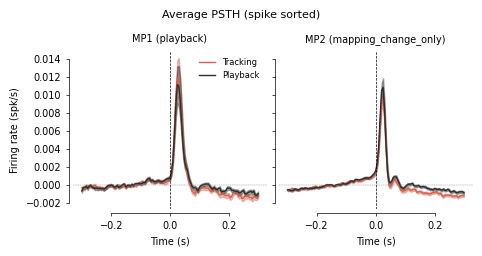

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12/2.54, 6/2.54), sharey=True)

ss_label = "spike sorted" if spike_sorted else "unsorted"

for ax, (mean_track, sem_track, mean_pb, sem_pb, mp_label) in zip(
    axes,
    [(mean_track_mp1, sem_track_mp1, mean_pb_mp1, sem_pb_mp1, 'MP1 (playback)'),
     (mean_track_mp2, sem_track_mp2, mean_pb_mp2, sem_pb_mp2, 'MP2 (mapping_change_only)')]
):
    ax.fill_between(time, mean_track - sem_track, mean_track + sem_track,
                    color='#D6604D', alpha=0.4)
    ax.fill_between(time, mean_pb - sem_pb, mean_pb + sem_pb,
                    color='#2C2C2A', alpha=0.4)
    ax.plot(time, mean_track, color='#D6604D', lw=1, label='Tracking')
    ax.plot(time, mean_pb, color='#2C2C2A', lw=1, label='Playback')
    ax.axvline(0, color='k', lw=0.5, ls='--')
    ax.axhline(0, color='gray', lw=0.3, ls='--')
    ax.set_title(mp_label, fontsize=7)
    ax.set_xlabel('Time (s)', fontsize=7)
    sns.despine(ax=ax, offset=3, trim=True)

axes[0].set_ylabel('Firing rate (spk/s)', fontsize=7)
axes[0].legend(frameon=False, fontsize=6)
fig.suptitle(f'Average PSTH ({ss_label})', fontsize=8, y=1.02)
plt.tight_layout(pad=0.5)
plt.savefig(save_directory + f'mean_traj_{ss_label.replace(" ", "_")}.pdf', dpi=300, bbox_inches='tight')
plt.show()

### Peak analysis per trigger situation (first quarter, second,..., last quarter in a session)

In [14]:
n_pre = int(t_pre/dt-1)
halves = [(0.0, 0.5), (0.5, 1.0)]

def extract_halves(n_data, f_data):
    results = {}
    for start, end in halves:
        results[(start, end)] = extract_traj_subset(
            n_data, f_data, t_pre, t_post, dt,
            overlap_thresh=1.0, n_pre=n_pre, full=True,
            trial_start=start, trial_end=end)
    return results

results_by_half_mp2 = extract_halves(n_data_mp2, f_data_mp2)
results_by_half_mp1 = extract_halves(n_data_mp1, f_data_mp1)

extract_traj_subset:   0%|          | 0/33 [00:00<?, ?it/s]

extract_traj_subset:   0%|          | 0/33 [00:00<?, ?it/s]

extract_traj_subset:   0%|          | 0/14 [00:00<?, ?it/s]

extract_traj_subset:   0%|          | 0/14 [00:00<?, ?it/s]

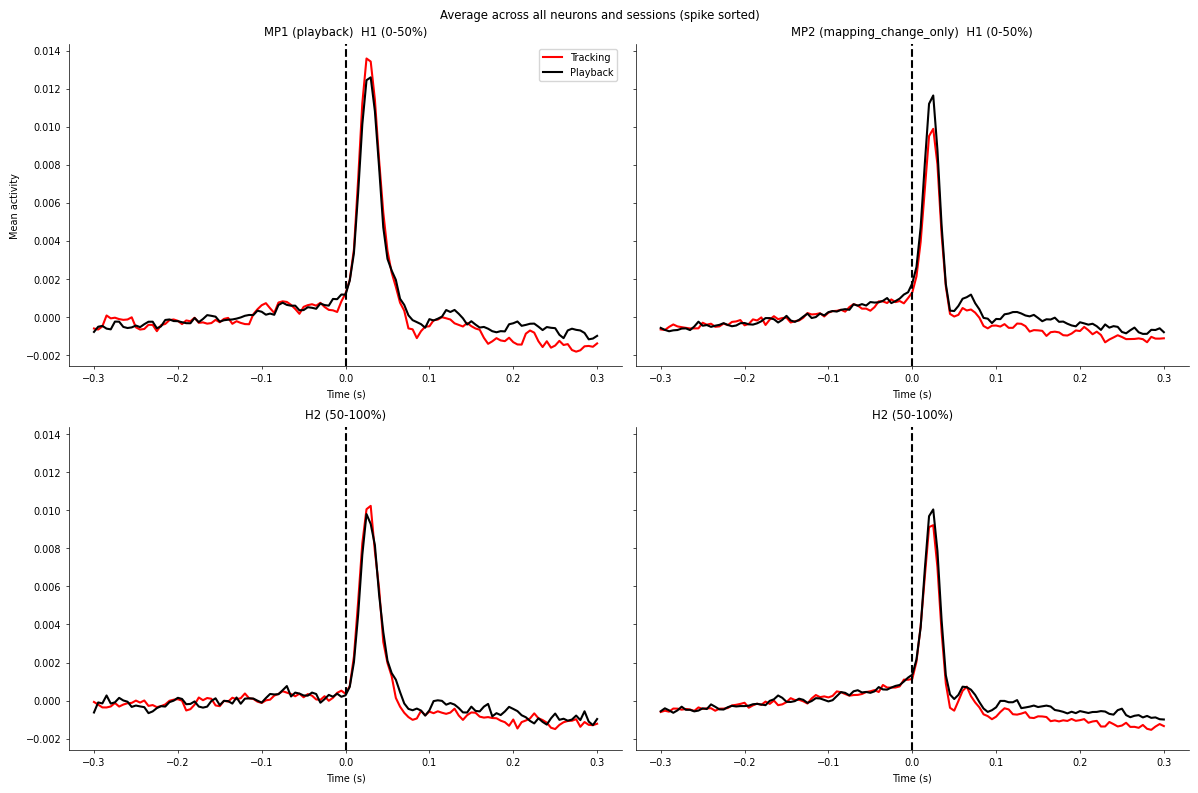

In [15]:
half_labels = ['H1 (0-50%)', 'H2 (50-100%)']
ss_label = "spike sorted" if spike_sorted else "unsorted"

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)

for col, (results_by_half, mp_label) in enumerate(
    [(results_by_half_mp1, 'MP1 (playback)'), (results_by_half_mp2, 'MP2 (mapping_change_only)')]):
    for row, (start, end) in enumerate(halves):
        ax = axes[row, col]
        all_traj_track, all_traj_pb, all_traj_mock, *_ = results_by_half[(start, end)]
        mean_traj_track = np.nanmean(np.concatenate(all_traj_track, axis=1), axis=1)
        mean_traj_pb = np.nanmean(np.concatenate(all_traj_pb, axis=1), axis=1)
        ax.plot(time, mean_traj_track, c='red', label='Tracking')
        ax.plot(time, mean_traj_pb, c='black', label='Playback')
        ax.axvline(0, color='k', linestyle='--')
        if row == 0: ax.set_title(f'{mp_label}  {half_labels[row]}')
        else: ax.set_title(half_labels[row])
        ax.set_xlabel("Time (s)")

axes[0, 0].set_ylabel("Mean activity")
axes[0, 0].legend()
plt.suptitle(f"Average across all neurons and sessions ({ss_label})")
plt.tight_layout()
plt.show()

In [16]:
n_pre = int(t_pre/dt - 1)

groups_mp2 = {'beg': (n_data_mp2_beg, f_data_mp2_beg), 'exp': (n_data_mp2_exp, f_data_mp2_exp)}
groups_mp1 = {'beg': (n_data_mp1_beg, f_data_mp1_beg), 'exp': (n_data_mp1_exp, f_data_mp1_exp)}

def extract_group_halves(groups_dict):
    results = {}
    for group_name, (n_data, f_data) in groups_dict.items():
        results[group_name] = {}
        for start, end in halves:
            results[group_name][(start, end)] = extract_traj_subset(
                n_data, f_data, t_pre, t_post, dt,
                overlap_thresh=1.0, n_pre=n_pre, full=True,
                trial_start=start, trial_end=end)
    return results

results_mp2 = extract_group_halves(groups_mp2)
results_mp1 = extract_group_halves(groups_mp1)

extract_traj_subset:   0%|          | 0/16 [00:00<?, ?it/s]

extract_traj_subset:   0%|          | 0/16 [00:00<?, ?it/s]

extract_traj_subset:   0%|          | 0/16 [00:00<?, ?it/s]

extract_traj_subset:   0%|          | 0/16 [00:00<?, ?it/s]

extract_traj_subset:   0%|          | 0/7 [00:00<?, ?it/s]

extract_traj_subset:   0%|          | 0/7 [00:00<?, ?it/s]

extract_traj_subset:   0%|          | 0/7 [00:00<?, ?it/s]

extract_traj_subset:   0%|          | 0/7 [00:00<?, ?it/s]

In [17]:
def build_traj(results_dict):
    traj = {}
    for q in halves:
        track_beg, pb_beg, mock_beg, *_ = results_dict['beg'][q]
        track_exp, pb_exp, mock_exp, *_ = results_dict['exp'][q]
        traj[q] = {
            'track': {'beg': track_beg, 'exp': track_exp},
            'pb':    {'beg': pb_beg,    'exp': pb_exp},
        }
    return traj

traj_by_half_mp2 = build_traj(results_mp2)
traj_by_half_mp1 = build_traj(results_mp1)

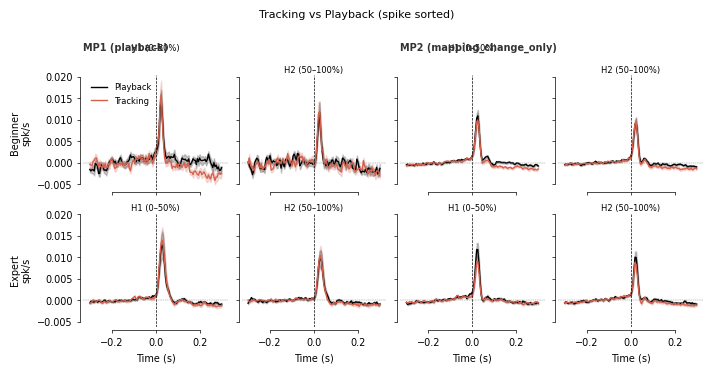

In [18]:
halves = [(0.0, 0.5), (0.5, 1.0)]
half_labels = ['H1 (0–50%)', 'H2 (50–100%)']
expertise_levels = ['beg', 'exp']
expertise_labels = ['Beginner', 'Expert']
ss_label = "spike sorted" if spike_sorted else "unsorted"
C_TRACK, C_PB = '#D6604D', 'black'

fig, axes = plt.subplots(2, 4, figsize=(18/2.54, 9/2.54), sharey='all', sharex=True)

mp_datasets = [
    (traj_by_half_mp1, 'MP1 (playback)'),
    (traj_by_half_mp2, 'MP2 (mapping_change_only)'),
]

for col, (traj_by_half, mp_label) in enumerate(mp_datasets):
    for row, (exp, exp_label) in enumerate(zip(expertise_levels, expertise_labels)):
        for h_idx, (q, q_label) in enumerate(zip(halves, half_labels)):
            ax = axes[row, col*2 + h_idx]
            track = traj_by_half[q]['track'][exp]
            pb = traj_by_half[q]['pb'][exp]
            mean_track = np.nanmean(np.concatenate(track, axis=1), axis=1)
            mean_pb = np.nanmean(np.concatenate(pb, axis=1), axis=1)
            cat_track = np.concatenate(track, axis=1)
            cat_pb = np.concatenate(pb, axis=1)
            sem_track = np.nanstd(cat_track, axis=1) / np.sqrt(max(cat_track.shape[1], 1))
            sem_pb = np.nanstd(cat_pb, axis=1) / np.sqrt(max(cat_pb.shape[1], 1))
            ax.fill_between(time, mean_track - sem_track, mean_track + sem_track,
                            color=C_TRACK, alpha=0.2)
            ax.fill_between(time, mean_pb - sem_pb, mean_pb + sem_pb,
                            color=C_PB, alpha=0.2)
            ax.plot(time, mean_pb, color=C_PB, lw=1, label='Playback')
            ax.plot(time, mean_track, color=C_TRACK, lw=1, label='Tracking')
            ax.axvline(0, color='k', lw=0.5, ls='--')
            ax.axhline(0, color='gray', lw=0.3, ls='--')
            ax.set_title(q_label, fontsize=6, pad=2)
            if col == 0 and h_idx == 0:
                ax.set_ylabel(f'{exp_label}\nspk/s', fontsize=7)
            if row == 1:
                ax.set_xlabel('Time (s)', fontsize=7)
            sns.despine(ax=ax, offset=2, trim=True)

# MP column labels via the top-row axes' titles
for col, (_, mp_label) in enumerate(mp_datasets):
    axes[0, col*2].set_title(mp_label, fontsize=7, fontweight='bold', loc='left', pad=18, color='#333333')

axes[0, 0].legend(frameon=False, fontsize=6, loc='upper left')
fig.suptitle(f'Tracking vs Playback ({ss_label})', fontsize=8, y=1.02)
plt.tight_layout(pad=0.8)
plt.savefig(save_directory + f'traj_by_half_{ss_label.replace(" ", "_")}.pdf', dpi=300, bbox_inches='tight')
plt.show()

### Plot AUC(playback - tracking) en fonction du moment dans la session et de l'exposition. 

In [19]:
def get_diff(traj_by_half, q, group):
    track = np.concatenate(traj_by_half[q]['track'][group], axis=1)
    pb = np.concatenate(traj_by_half[q]['pb'][group], axis=1)
    return pb - track

# MP2
d_beg_h1_mp2 = get_diff(traj_by_half_mp2, (0.0, 0.5), 'beg')
d_beg_h2_mp2 = get_diff(traj_by_half_mp2, (0.5, 1.0), 'beg')
d_exp_h1_mp2 = get_diff(traj_by_half_mp2, (0.0, 0.5), 'exp')
d_exp_h2_mp2 = get_diff(traj_by_half_mp2, (0.5, 1.0), 'exp')

# MP1
d_beg_h1_mp1 = get_diff(traj_by_half_mp1, (0.0, 0.5), 'beg')
d_beg_h2_mp1 = get_diff(traj_by_half_mp1, (0.5, 1.0), 'beg')
d_exp_h1_mp1 = get_diff(traj_by_half_mp1, (0.0, 0.5), 'exp')
d_exp_h2_mp1 = get_diff(traj_by_half_mp1, (0.5, 1.0), 'exp')

In [20]:
idx_start = np.searchsorted(time, 0)
idx_end = np.searchsorted(time, 0.1)

def compute_auc(diff, time, idx_start, idx_end):
    from scipy.integrate import trapezoid
    return trapezoid(diff[idx_start:idx_end, :], x=time[idx_start:idx_end], axis=0)

# MP2
auc_beg_h1_mp2 = compute_auc(d_beg_h1_mp2, time, idx_start, idx_end)
auc_beg_h2_mp2 = compute_auc(d_beg_h2_mp2, time, idx_start, idx_end)
auc_exp_h1_mp2 = compute_auc(d_exp_h1_mp2, time, idx_start, idx_end)
auc_exp_h2_mp2 = compute_auc(d_exp_h2_mp2, time, idx_start, idx_end)

# MP1
auc_beg_h1_mp1 = compute_auc(d_beg_h1_mp1, time, idx_start, idx_end)
auc_beg_h2_mp1 = compute_auc(d_beg_h2_mp1, time, idx_start, idx_end)
auc_exp_h1_mp1 = compute_auc(d_exp_h1_mp1, time, idx_start, idx_end)
auc_exp_h2_mp1 = compute_auc(d_exp_h2_mp1, time, idx_start, idx_end)

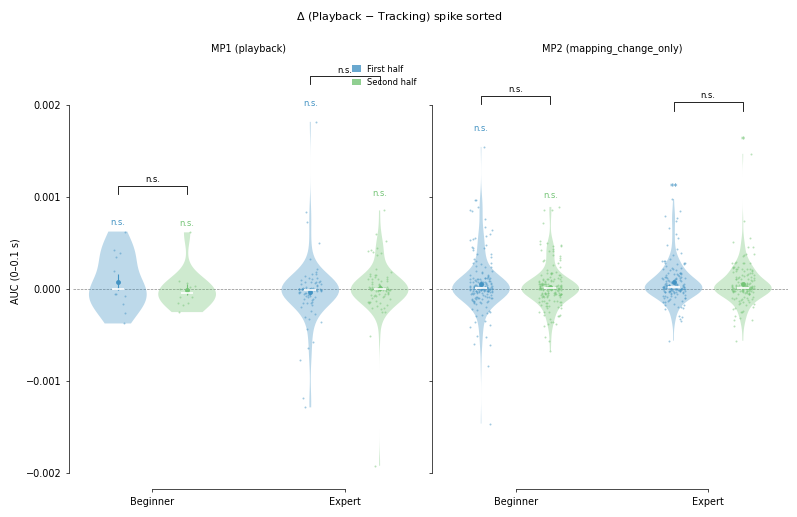

In [21]:
# ── AUC violin: MP1 vs MP2 side by side ────────────────────
C_H1, C_H2 = '#4393C3', '#74C476'
ALPHA_V, ALPHA_S = 0.35, 0.5
groups_plot = ['Beginner', 'Expert']
ss_label = "spike sorted" if spike_sorted else "unsorted"

datasets = [
    ('MP1 (playback)', [
        [auc_beg_h1_mp1, auc_beg_h2_mp1],
        [auc_exp_h1_mp1, auc_exp_h2_mp1],
    ]),
    ('MP2 (mapping_change_only)', [
        [auc_beg_h1_mp2, auc_beg_h2_mp2],
        [auc_exp_h1_mp2, auc_exp_h2_mp2],
    ]),
]

fig, axes = plt.subplots(1, 2, figsize=(10/2.54*2, 5/2.54*2.5), sharey=True)
conditions = ['First half', 'Second half']

for ax, (mp_label, data_all) in zip(axes, datasets):
    n_groups = len(groups_plot)
    n_conditions = len(conditions)
    n_comparisons = n_groups * n_conditions + n_groups
    offsets = [-0.18, 0.18]
    colors = [C_H1, C_H2]
    positions = np.arange(n_groups)

    for c_idx, (cond, color, offset) in enumerate(zip(conditions, colors, offsets)):
        for g_idx, (group, gdata) in enumerate(zip(groups_plot, data_all)):
            y = gdata[c_idx]; xpos = positions[g_idx] + offset
            vp = ax.violinplot(y, positions=[xpos], widths=0.3,
                               showmeans=False, showmedians=False, showextrema=False)
            for body in vp['bodies']:
                body.set_facecolor(color); body.set_alpha(ALPHA_V); body.set_edgecolor('none')
            jitter = np.random.uniform(-0.06, 0.06, size=len(y))
            ax.scatter(np.full(len(y), xpos) + jitter, y, s=2, color=color, alpha=ALPHA_S, linewidths=0, zorder=3)
            mean = np.mean(y); sem = np.std(y, ddof=1)/np.sqrt(len(y))
            ax.errorbar(xpos, mean, yerr=sem, fmt='o', ms=3.5, color=color,
                        ecolor=color, elinewidth=0.8, capsize=2, capthick=0.8, zorder=5, markeredgewidth=0)
            ax.plot(xpos, np.median(y), '_', color='white', ms=8, mew=1.2, zorder=6)
            _, p = wilcoxon(y); p_c = min(p*n_comparisons, 1.0)
            stars = '***' if p_c<0.001 else ('**' if p_c<0.01 else ('*' if p_c<0.05 else 'n.s.'))
            y_star = np.max(y)+(np.max(y)-np.min(y))*0.05
            ax.text(xpos, y_star, stars, ha='center', va='bottom', fontsize=6, color=color)

    # Paired tests
    y_range = ax.get_ylim()[1]-ax.get_ylim()[0]
    for g_idx, (group, gdata) in enumerate(zip(groups_plot, data_all)):
        y_h1, y_h2 = gdata; _, p = wilcoxon(y_h1, y_h2); p_c = min(p*n_groups, 1.0)
        stars = '***' if p_c<0.001 else ('**' if p_c<0.01 else ('*' if p_c<0.05 else 'n.s.'))
        x1, x2 = positions[g_idx]+offsets[0], positions[g_idx]+offsets[1]
        y_bracket = max(np.max(y_h1), np.max(y_h2))+y_range*0.12
        ax.plot([x1,x1,x2,x2], [y_bracket-y_range*0.02, y_bracket, y_bracket, y_bracket-y_range*0.02], lw=0.6, color='k')
        ax.text((x1+x2)/2, y_bracket+y_range*0.005, stars, ha='center', va='bottom', fontsize=6)

    ax.axhline(0, lw=0.5, ls='--', color='#888888', zorder=0)
    ax.set_xticks(positions); ax.set_xticklabels(groups_plot, fontsize=7)
    ax.set_title(mp_label, fontsize=7, pad=4)
    sns.despine(ax=ax, offset=3, trim=True)

axes[0].set_ylabel('AUC (0–0.1 s)', fontsize=7)
legend_handles = [
    mpatches.Patch(facecolor=C_H1, alpha=0.8, label='First half'),
    mpatches.Patch(facecolor=C_H2, alpha=0.8, label='Second half'),
]
axes[0].legend(handles=legend_handles, frameon=False, fontsize=6, loc='upper right', handlelength=1, handleheight=0.8)
fig.suptitle(f'$\Delta$ (Playback $-$ Tracking) {ss_label}', fontsize=8, y=1.02)
plt.tight_layout(pad=0.5)
plt.savefig(save_directory+f'fig_auc_{ss_label.replace(" ", "_")}.pdf', dpi=300, bbox_inches='tight')
plt.savefig(save_directory+f'fig_auc_{ss_label.replace(" ", "_")}.svg', bbox_inches='tight')
plt.show()

In [27]:
%matplotlib qt

In [ ]:
# %% LMM Analysis: Track vs Playback, MP1 vs MP2
# 每个神经元贡献 2 行（Track + PB），condition 作为显式因子
# Requires: traj_by_half_mp1, traj_by_half_mp2, time, save_directory
# Run after the AUC violin plot cell

import sys
sys.path.insert(0, r'C:\Users\PenPen\Ferret\Analysis')                                                           
                                                                                                                 
# Forced reload
import lmm_analysis
import importlib
importlib.reload(lmm_analysis)

from lmm_analysis import run_lmm_analysis, compare_random_effect_structures

result_lmm, df_lmm = run_lmm_analysis(
    traj_by_half_mp1, traj_by_half_mp2, time, save_directory
)
compare_random_effect_structures(df_lmm)

Building LMM DataFrame (long format: Track + PB as separate rows)...
  Total rows: 1684 (648 neurons x 2 conditions)
  Unique sessions: 46
    MP1 (playback): 14 sessions, 194 neurons
    MP2 (mapping_change_only): 32 sessions, 648 neurons

-- Data Summary (mean response +/- SEM) --
                                                       mean      std  count      sem
group                     condition expertise half                                  
MP1 (playback)            Playback  Beginner  H1    0.00384  0.00313     13  0.00087
                                              H2    0.00197  0.00231     13  0.00064
                                    Expert    H1    0.00399  0.00811     84  0.00088
                                              H2    0.00281  0.00526     84  0.00057
                          Track     Beginner  H1    0.00305  0.00254     13  0.00070
                                              H2    0.00205  0.00255     13  0.00071
                                    

[{'name': 'Fixed effects only',
  'llf': np.float64(6724.711250766699),
  'n_params': 18,
  'aic': np.float64(-13413.422501533398),
  'bic': np.float64(-13315.701812026957)},
 {'name': 'Random Intercept',
  'llf': np.float64(6724.711250766699),
  'n_params': 18,
  'aic': np.float64(-13413.422501533398),
  'bic': np.float64(-13315.701812026957)},
 {'name': 'Random Int + Slope (condition)',
  'llf': np.float64(6725.16291125314),
  'n_params': 19,
  'aic': np.float64(-13412.32582250628),
  'bic': np.float64(-13309.176205805037)}]